# 09_01.Model Comparison(예측)

## 1.기본 package 설정

In [ ]:
# 그래프에서 한글 폰트 인식하기
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

#  *** 런타임 다시 시작

In [1]:
## 1.기본
import numpy as np  # numpy 패키지 가져오기
import matplotlib.pyplot as plt # 시각화 패키지 가져오기
import seaborn as sns # 시각화

## 2.데이터 가져오기
import pandas as pd # csv -> dataframe으로 전환

## 3.데이터 전처리
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import LabelEncoder

# 4. 훈련/검증용 데이터 분리
from sklearn.model_selection import train_test_split

## 5.모델구축
from sklearn.linear_model import Lasso                     # 회귀분석(예측)
from sklearn.neural_network import MLPRegressor            # 다층인공신경망(예측)
from sklearn.svm import SVR                                # 서포트 벡터 머신(SVM)(예측)
from sklearn.tree import DecisionTreeRegressor, plot_tree  # 결정 트리(예측)
from sklearn.ensemble import RandomForestRegressor         # 랜덤 포레스트(예측)
from xgboost import XGBRegressor                           # XG부스팅(예측)
from sklearn.neighbors import KNeighborsRegressor          # K-최근접 이웃(예측)

## 6.모델검정
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 7.최적화
from sklearn.model_selection import GridSearchCV # 하이퍼파라미터 튜닝

## 2.데이터 불러오기

### 2.1 구글 드라이브와 연결

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2.2 데이터 프레임으로 저장
- 원본데이터(csv)를 dataframe 형태로 가져오기(pandas)

In [3]:
housing_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/주택가격.csv', encoding="cp949")
housing_df.head()

,id,가격,연면적,품질,상태,건축년도,리모델링년도,지하면적,차고면적,면적_1층,면적_2층,주거유형,판매유형,판매조건
0,1,208500,8450,7,5,2003,2003,856,548,856,854,1,1,1
1,2,181500,9600,6,8,1976,1976,1262,460,1262,0,1,1,1
2,3,223500,11250,7,5,2001,2002,920,608,920,866,1,1,1
3,4,140000,9550,7,5,1915,1970,756,642,961,756,1,1,2
4,5,250000,14260,8,5,2000,2000,1145,836,1145,1053,1,1,1


### 2.3 자료구조 살펴보기

In [ ]:
housing_df.shape

In [ ]:
housing_df.info()

In [ ]:
housing_df.columns

## 3.데이터 전처리

### 3.1 필요없는 변수 제거

In [4]:
housing_df = housing_df.drop (['id'], axis=1)
housing_df.head()

,가격,연면적,품질,상태,건축년도,리모델링년도,지하면적,차고면적,면적_1층,면적_2층,주거유형,판매유형,판매조건
0,208500,8450,7,5,2003,2003,856,548,856,854,1,1,1
1,181500,9600,6,8,1976,1976,1262,460,1262,0,1,1,1
2,223500,11250,7,5,2001,2002,920,608,920,866,1,1,1
3,140000,9550,7,5,1915,1970,756,642,961,756,1,1,2
4,250000,14260,8,5,2000,2000,1145,836,1145,1053,1,1,1


### 3.2 범주형 변수 처리
- 가변수 처리시 문자로 처리를 해야 변수명 구분이 쉬움

In [5]:
housing_df['주거유형'] = housing_df['주거유형'].replace ([1,2,3,4,5], ['단독주택','2가구변경','듀플렉스','타운젠트바깥쪽','타운젠트안쪽'])
housing_df['판매유형'] = housing_df['판매유형'].replace ([1,2], ['보증증서','법원관리증서'])
housing_df['판매조건'] = housing_df['판매조건'].replace ([1,2], ['정상판매','압류및공매도'])
housing_df.head()

,가격,연면적,품질,상태,건축년도,리모델링년도,지하면적,차고면적,면적_1층,면적_2층,주거유형,판매유형,판매조건
0,208500,8450,7,5,2003,2003,856,548,856,854,단독주택,보증증서,정상판매
1,181500,9600,6,8,1976,1976,1262,460,1262,0,단독주택,보증증서,정상판매
2,223500,11250,7,5,2001,2002,920,608,920,866,단독주택,보증증서,정상판매
3,140000,9550,7,5,1915,1970,756,642,961,756,단독주택,보증증서,압류및공매도
4,250000,14260,8,5,2000,2000,1145,836,1145,1053,단독주택,보증증서,정상판매


## 4.데이터 탐색

### 4.1 EDA 데이터 탐색

In [ ]:
# 수치형 변수
housing_df.describe().round(2).T

In [ ]:
# 범주형 변수
# lecture_df.columns
categorical_features=['주거유형', '판매유형', '판매조건']

for col in categorical_features:
    cat = housing_df[col].value_counts()
    print(cat)

### 4.2 그래프 그리기

In [ ]:
# 한글 폰트 인식
plt.rc('font', family='NanumBarunGothic')

In [ ]:
# 수치형 변수
g = sns.pairplot(housing_df)

In [ ]:
# 변수별 선형회귀직선
variables = ['연면적', '품질', '상태', '건축년도', '리모델링년도', '지하면적',
             '차고면적', '면적_1층', '면적_2층']

for var in variables:
    plt.figure()
    sns.regplot(x = var, y = '가격', data = housing_df).set(title=f'{var} and 가격에 따른 회귀직선');

In [ ]:
# 범주형 변수
for col in categorical_features:
    sns.countplot(x=col, data = housing_df)
    plt.show()

### 4.3 base accuracy


In [ ]:
# base accuracy
housing_df['가격'].mean()

## 5.훈련/테스트용 데이터 분할


### 5.1 data와 target으로 분리
- data: X, target: y 로 분리

- X 추출


In [6]:
X = housing_df.drop (['가격'], axis=1)
X.head()

,연면적,품질,상태,건축년도,리모델링년도,지하면적,차고면적,면적_1층,면적_2층,주거유형,판매유형,판매조건
0,8450,7,5,2003,2003,856,548,856,854,단독주택,보증증서,정상판매
1,9600,6,8,1976,1976,1262,460,1262,0,단독주택,보증증서,정상판매
2,11250,7,5,2001,2002,920,608,920,866,단독주택,보증증서,정상판매
3,9550,7,5,1915,1970,756,642,961,756,단독주택,보증증서,압류및공매도
4,14260,8,5,2000,2000,1145,836,1145,1053,단독주택,보증증서,정상판매


- target(y) 추출
- y 값을 series에서 배열로 변환

In [7]:
y = housing_df['가격']
y.head()

0    208500
1    181500
2    223500
3    140000
4    250000
Name: 가격, dtype: int64

In [8]:
# 선형모델의 y 값 표준화
y_std = StandardScaler().fit_transform(y[:, np.newaxis]).flatten()
y_std

<ipython-input-8-062dc99c69b7>:2: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y_std = StandardScaler().fit_transform(y[:, np.newaxis]).flatten()


array([ 0.87174655,  0.3601134 ,  1.15598719, ...,  1.97081036,
       -0.38601829, -0.28416539])

### 5.2 훈련용 및 테스트용 데이터 분할
- test_size: 검증데이터 30%
- random_state : random seed 번호 = 1
- stratify : y(클래스)의 비율에 따라 분할(분류모형일때 사용)

In [9]:
# linear형 모델: y값 표준화
X_train, X_test, y_train_std, y_test_std = train_test_split(X, y_std,
                                                    test_size = 0.3,
                                                    random_state = 1)

In [10]:
# tree형 모델:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.3,
                                                    random_state = 1)

In [ ]:
y_train_std.shape

(826,)

In [ ]:
y_train.info()

<class 'pandas.core.series.Series'>
Int64Index: 826 entries, 433 to 1061
Series name: 가격
Non-Null Count  Dtype
--------------  -----
826 non-null    int64
dtypes: int64(1)
memory usage: 12.9 KB


## 6.pipeline으로 데이터 전처리
https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html
- R에서 recipe
- 범주형 변수: OneHotEncoder
- 수치형 변수:
- 선형모델은 StandardScaler 로 표준화
- tree형 모델은 데이터 원형 사용

### 6.1 preprocess 세팅(linear형 모델)

In [11]:
# pipeline으로 세팅
# 수치형 변수(y는 제외)
numeric_features = ['연면적', '품질', '상태', '건축년도', '리모델링년도',
                    '지하면적', '차고면적', '면적_1층', '면적_2층']

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='mean')), # 누락된 값은 중앙값으로 처리
        ('scaler', StandardScaler())
    ]
)

# 범주형 변수(y는 제외)
categorical_features=['주거유형', '판매유형', '판매조건']

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant',
                                  fill_value='missing')),  # 누락된 값은 missing으로 상수 처리
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

# preprocessor로 데이터 변환 세팅
preprocessor_line = ColumnTransformer(                               # preprocessor_cont로 수정
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [12]:
preprocessor_line

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['연면적', '품질', '상태', '건축년도', '리모델링년도', '지하면적',
                                  '차고면적', '면적_1층', '면적_2층']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['주거유형', '판매유형', '판매조건'])])

In [13]:
pd.DataFrame(preprocessor_line.fit_transform(X_train)).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,-0.596577,-0.709282,1.204375,0.067463,-0.614537,-0.610066,0.965758,-1.005785,-0.789563,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,0.494475,-1.529824,-0.588082,-0.106458,-0.860567,-0.093881,-0.052596,-0.425396,-0.789563,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,-0.075530,-0.709282,-0.588082,0.206599,-0.417714,-0.265943,-2.343893,-0.618859,1.430503,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,-2.147846,-0.709282,-0.588082,0.067463,-0.614537,-0.981073,-0.010165,-1.422939,0.875486,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
4,-0.894487,-0.709282,-1.484311,-1.115198,-1.598655,-0.265943,-1.070950,-0.618859,0.320470,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


### 6.2 preprocess 세팅(tree형 모델)

In [14]:
# pipeline으로 세팅
# 수치형 변수(y는 제외)
numeric_features = ['연면적', '품질', '상태', '건축년도', '리모델링년도',
                    '지하면적', '차고면적', '면적_1층', '면적_2층']

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='mean')), # 누락된 값은 중앙값으로 처리
        #('scaler', StandardScaler())                # tree형 모델은 데이터 원형 사용
    ]
)

# 범주형 변수(y는 제외)
categorical_features=['주거유형', '판매유형', '판매조건']

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant',
                                  fill_value='missing')),  # 누락된 값은 missing으로 상수 처리
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

# preprocessor로 데이터 변환 세팅
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [15]:
preprocessor_tree

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer())]),
                                 ['연면적', '품질', '상태', '건축년도', '리모델링년도', '지하면적',
                                  '차고면적', '면적_1층', '면적_2층']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['주거유형', '판매유형', '판매조건'])])

In [16]:
pd.DataFrame(preprocessor_tree.fit_transform(X_train)).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,7244.0,5.0,7.0,1970.0,1970.0,768.0,624.0,768.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,10921.0,4.0,5.0,1965.0,1965.0,960.0,432.0,960.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,9000.0,5.0,5.0,1974.0,1974.0,896.0,0.0,896.0,896.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,2016.0,5.0,5.0,1970.0,1970.0,630.0,440.0,630.0,672.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
4,6240.0,5.0,4.0,1936.0,1950.0,896.0,240.0,896.0,448.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


## 7.모델만들기 (모델 설정)
- R에서 workflow
- 예측모델: 000_reg
- 분류모델: 000_clf

### 7.1 pipeline으로 모델 연결

In [17]:
# linear형 모델

lr_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor_line),
        ("lr_reg", Lasso())                           # LinearRegression(Lasso)
    ]
)


mlp_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor_line),
        ("mlp_reg", MLPRegressor())
    ]
)

svr_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor_line),
        ("svr_reg", SVR())
    ]
)

knn_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor_line),
        ("knn_reg", KNeighborsRegressor())
    ]
)

# tree형 모델

dt_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("dt_reg", DecisionTreeRegressor())
    ]
)

rf_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("rf_reg", RandomForestRegressor())
    ]
)

xgb_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("xgb_reg", XGBRegressor(learning_rate=0.1))      # learning_rate=0.1
    ]
)

### 7.2 하이퍼파라미터 세팅
- 그리드 서치를 사용한 머신 러닝 모델 세부 튜닝
- 기계학습 모델의 성능을 결정하는 하이퍼 파라미터 튜닝

In [18]:
# linear형 모델

lr_grid = {
    "lr_reg__tol" : np.logspace(-5,-1,5) ,     # [1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01]
    "lr_reg__alpha" : np.logspace(-5,-1,5),    # [0.00001, 0.0001, 0.001, 0.01, 0.1]
}

mlp_grid = {
    'mlp_reg__hidden_layer_sizes': [(5, 5),(5, 10),(10, 5),(10, 10)],
    'mlp_reg__alpha': np.logspace(-5, -3, 3),
}

svr_grid = {
    "svr_reg__kernel" : ["rbf", "linear"] ,
    'svr_reg__C': [0.1, 1, 10, 20],
    'svr_reg__gamma': [1, 0.1, 0.01, 0.001],
}

knn_grid = {
    'knn_reg__n_neighbors' : [3, 5, 7, 9],
    'knn_reg__weights' : ['uniform','distance'],
    'knn_reg__metric' : ['minkowski','euclidean','manhattan']
}

# tree형 모델

dt_grid = {
    "dt_reg__ccp_alpha" :np.logspace(-5,-3,3) ,     # [1.e-05, 1.e-04, 1.e-03]
    'dt_reg__max_depth': [1, 3, 5],
    'dt_reg__min_samples_leaf': [10, 30, 50],
}

rf_grid = {
    "rf_reg__ccp_alpha" :np.logspace(-5,-3,3) ,     # [1.e-05, 1.e-04, 1.e-03]
    'rf_reg__n_estimators' : [10, 50, 100],
    'rf_reg__max_depth' : [1, 5, 9],
}

xgb_grid = {
    'xgb_reg__n_estimators' : [10, 50, 100],
    'xgb_reg__gamma': [1, 5, 10],             # gain 값이 gamma 이상일 경우 자식 노드를 생성
    'xgb_reg__subsample': [0.25, 0.5, 1.0],   # 각각의 스탭마다 사용할 샘플의 비율 [0~1]
}

### 7.3 하이퍼파라미터 그리드 만들기

In [19]:
line_pipe = [lr_pipe, mlp_pipe, svr_pipe, knn_pipe]

line_grids = [lr_grid, mlp_grid, svr_grid, knn_grid]

line_models = {
    0:'lr_gs',
    1:'mlp_gs',
    2:'svr_gs',
    3:'knn_gs',
}

In [20]:
tree_pipe = [dt_pipe, rf_pipe, xgb_pipe]

tree_grids = [dt_grid, rf_grid, xgb_grid]

tree_models = {
    0:'dt_gs',
    1:'rf_gs',
    2:'xgb_gs'
}

## 8.모델 훈련(모델 학습)
- machine learning

### 8.1 모델 훈련하기(learning)

In [32]:
gs_results = {}
gs_cv_results = {}
gs_best_params = {}
test_r2 = {}

for idx , (grid , model) in enumerate(zip(line_grids , line_pipe)) :
    gs = GridSearchCV(estimator = model,         # model
                      param_grid = grid,         #grid
                      scoring='r2',              # mse, r2
                      cv = 5,                    # cv = 5
                      n_jobs = -1,
                      verbose = 10,              # 프로세스 진행사항 확인
                      return_train_score = True) # 훈련결과 저장
    gs_results[line_models.get(idx)] = gs.fit(X_train, y_train_std)
    gs_best_params[line_models.get(idx)] = gs.best_params_
    gs_cv_results[line_models.get(idx)] = gs.cv_results_
    y_pred = gs.predict(X_test)
    test_r2[line_models.get(idx)] = r2_score(y_test_std, y_pred)
    print(line_models.get(idx), " 학습 완료")

print("linear형 모델의 학습이 모두 완료되었습니다.")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
lr_gs  학습 완료
Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


mlp_gs  학습 완료
Fitting 5 folds for each of 32 candidates, totalling 160 fits
svr_gs  학습 완료
Fitting 5 folds for each of 24 candidates, totalling 120 fits
knn_gs  학습 완료
linear형 모델의 학습이 모두 완료되었습니다.


In [33]:
for idx , (grid , model) in enumerate(zip(tree_grids , tree_pipe)) :
    gs = GridSearchCV(estimator = model,         # model
                      param_grid = grid,         #grid
                      scoring='r2',              # mse, r2
                      cv = 5,                    # cv = 5
                      n_jobs = -1,
                      verbose = 10,              # 프로세스 진행사항 확인
                      return_train_score = True) # 훈련결과 저장
    gs_results[tree_models.get(idx)] = gs.fit(X_train , y_train)
    gs_best_params[tree_models.get(idx)] = gs.best_params_
    gs_cv_results[tree_models.get(idx)] = gs.cv_results_
    y_pred = gs.predict(X_test)
    test_r2[tree_models.get(idx)] = r2_score(y_test, y_pred)
    print(tree_models.get(idx), " 학습 완료")

print("tree형 모델의 학습이 모두 완료되었습니다.")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
dt_gs  학습 완료
Fitting 5 folds for each of 27 candidates, totalling 135 fits
rf_gs  학습 완료
Fitting 5 folds for each of 27 candidates, totalling 135 fits
xgb_gs  학습 완료
tree형 모델의 학습이 모두 완료되었습니다.


In [34]:
# 훈련모델 r2값 정리
list_tmp_df = []

for i, model in enumerate(gs_cv_results):
    train_r2 = pd.DataFrame({'model': model, 'r2': gs_results[model].best_score_}, index = [0])
    list_tmp_df.append(train_r2)

train_r2 = pd.concat(list_tmp_df, ignore_index = True)
train_r2 = train_r2.sort_values(by=["r2"], ascending= False)
train_r2

,model,r2
2,svr_gs,0.886035
1,mlp_gs,0.872077
0,lr_gs,0.857876
6,xgb_gs,0.857485
3,knn_gs,0.839915
5,rf_gs,0.824697
4,dt_gs,0.713838


In [35]:
test_r2 = pd.DataFrame([test_r2.keys() , test_r2.values()], index = ["model","r2"]).T
test_r2.sort_values(["r2"], ascending= False ,inplace=True)
test_r2

,model,r2
2,svr_gs,0.893079
6,xgb_gs,0.879388
0,lr_gs,0.870573
1,mlp_gs,0.863399
3,knn_gs,0.842992
5,rf_gs,0.836113
4,dt_gs,0.734833


In [ ]:
# 결과 통합
score_df = pd.merge(left = train_r2 , right = test_r2, how = "inner", on = "model")
score_df

,model,r2_x,r2_y
0,svr_gs,0.886035,0.893079
1,mlp_gs,0.872238,0.869662
2,lr_gs,0.857876,0.870573
3,xgb_gs,0.857485,0.879388
4,knn_gs,0.839915,0.842992
5,rf_gs,0.825808,0.840632
6,dt_gs,0.713838,0.734833


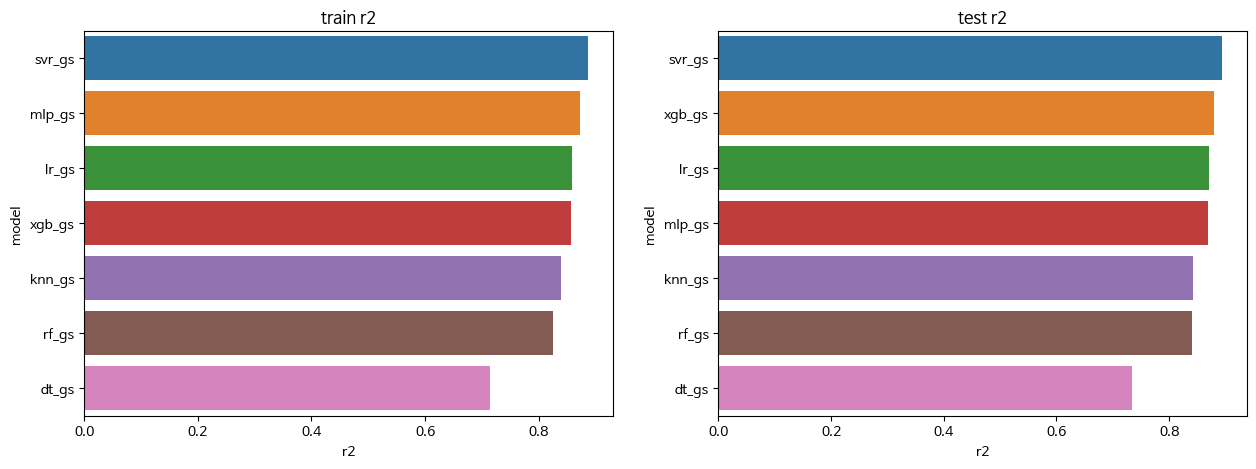

In [ ]:
# train, test r2 값 비교
plt.rc('font', family='NanumBarunGothic')

fig ,ax = plt.subplots(1, 2, figsize=(15, 5))
plt.subplot(1,2, 1)
plt.title("train r2")
sns.barplot(y="model", x="r2", data = train_r2)
plt.subplot(1,2, 2)
plt.title("test r2")
sns.barplot(y="model", x="r2", data = test_r2)
plt.show()


### 8.2 검증 곡선으로 Tuning 결과 확인
- 결과 표로 정리: https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_stats.html#sphx-glr-auto-examples-model-selection-plot-grid-search-stats-py
- 그래프로 정리: https://stackoverflow.com/questions/37161563/how-to-graph-grid-scores-from-gridsearchcv

In [ ]:
# 결과확인
gs_cv_results['svr_gs']

In [ ]:
# 분석결과를 표로 정리
list_tmp_df = []

for i, model in enumerate(gs_cv_results):
    results_df = pd.DataFrame(gs_cv_results[model])                   # lr_gs.cv_results_ -> gs_cv_results[model]
    results_df = results_df.sort_values(by=["rank_test_score"])
    results_df = results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]
    list_tmp_df.append(results_df)                                   # 추가

results_df = pd.concat(list_tmp_df, ignore_index = True)
results_df = results_df.sort_values(by=["mean_test_score"], ascending = False)
results_df

,params,rank_test_score,mean_test_score,std_test_score
37,"{'svr_reg__C': 10, 'svr_reg__gamma': 0.01, 'sv...",1,0.886035,0.018030
38,"{'svr_reg__C': 20, 'svr_reg__gamma': 0.01, 'sv...",2,0.884250,0.018546
25,"{'mlp_reg__alpha': 0.0001, 'mlp_reg__hidden_la...",1,0.872238,0.019933
39,"{'svr_reg__C': 1, 'svr_reg__gamma': 0.01, 'svr...",3,0.871825,0.020656
40,"{'svr_reg__C': 20, 'svr_reg__gamma': 0.001, 's...",4,0.869098,0.020501
...,...,...,...,...
169,"{'xgb_reg__gamma': 10, 'xgb_reg__n_estimators'...",22,-0.610546,0.134843
170,"{'xgb_reg__gamma': 1, 'xgb_reg__n_estimators':...",22,-0.610546,0.134843
171,"{'xgb_reg__gamma': 10, 'xgb_reg__n_estimators'...",25,-0.652756,0.141689
172,"{'xgb_reg__gamma': 5, 'xgb_reg__n_estimators':...",25,-0.652756,0.141689


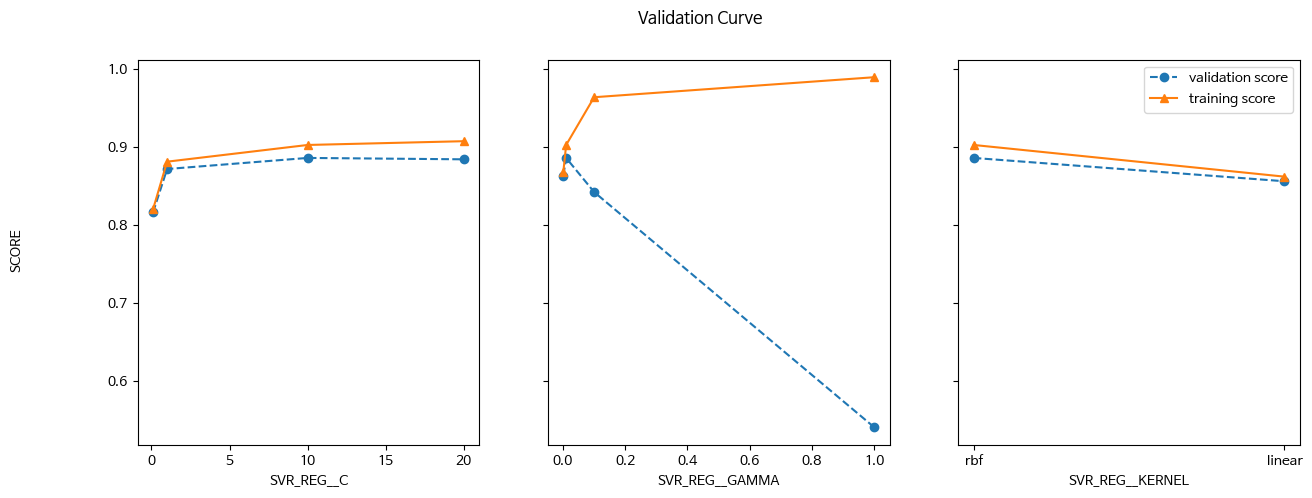

In [ ]:
# 튜닝결과 그래프
results = gs_results['svr_gs'].cv_results_                           # lr_gs -> gs_results['svr_gs']
means_test = results['mean_test_score']
means_train = results['mean_train_score']

masks = []
masks_names = list(gs_results['svr_gs'].best_params_.keys())        # lr_gs -> gs_results['svr_gs']
for p_k, p_v in gs_results['svr_gs'].best_params_.items():          # lr_gs -> gs_results['svr_gs']
    masks.append(list(results['param_'+p_k].data==p_v))

params = gs_results['svr_gs'].param_grid                            # lr_gs -> gs_results['svr_gs']

fig, ax = plt.subplots(1,len(params),
                       sharex='none',
                       sharey='all',
                       figsize=(15,5))
fig.suptitle('Validation Curve')
fig.text(0.04, 0.5, 'SCORE')

for i, p in enumerate(masks_names):
    m = np.stack(masks[:i] + masks[i+1:])
    best_parms_mask = m.all(axis=0)
    best_index = np.where(best_parms_mask)[0]
    x = np.array(params[p])
    y_1 = np.array(means_test[best_index])
    y_2 = np.array(means_train[best_index])
    ax[i].errorbar(x, y_1, linestyle='--', marker='o', label='validation score')
    ax[i].errorbar(x, y_2, linestyle='-', marker='^',label='training score' )
    ax[i].set_xlabel(p.upper())

plt.legend()
plt.show()

### 8.3 best 모델 설정

In [ ]:
# best 모델 파라미터 확인
print(gs_results['svr_gs'].best_score_)
print(gs_results['svr_gs'].best_params_)

0.8860346233451768
{'svr_reg__C': 10, 'svr_reg__gamma': 0.01, 'svr_reg__kernel': 'rbf'}


In [ ]:
# best 모델 파라미터를 최종모델로 훈련
best_reg = gs_results['svr_gs'].best_estimator_
best_reg.fit(X_train, y_train_std)                 # y_train -> y_train_std

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['연면적', '품질', '상태', '건축년도',
                                                   '리모델링년도', '지하면적', '차고면적',
                                                   '면적_1층', '면적_2층']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['주거유형', '판매유형', '판매조건'])])),
                ('svr_reg', SVR(C=10, gamma=0.01))])

In [ ]:
print(best_reg['svr_reg'])

SVR(C=10, gamma=0.01)


### 8.4 중요변수확인
- 중요도 점수 확인 안되는 모델
- MLP(ANN) : (, ) 2개층 레이어로 구성
- SVR: kerner = rgf일때
- KNN

In [ ]:
# 중요도 점수 계산
feature = best_reg['preprocessor'].get_feature_names_out()   # 수정
importances = best_reg["svr_reg"].feature_importances_        # 수정
importances = importances.flatten()                           # flatten() - 다차원 array를 1차원 array로 변환
output = pd.DataFrame([feature , importances],
                      index = ["feature","importances"]).T
output.sort_values(["importances"],
                   ascending= False ,
                   inplace=True)

In [ ]:
# 그래프 그리기

plt.rc('font', family='NanumBarunGothic')

fig ,ax = plt.subplots(figsize=(10, 5))
sns.set(font_scale = 1)
ax = sns.barplot(y="feature", x="importances", data=output)
plt.show()

## 9.모델 test 및 검정

### 9.1 검증용 데이터로 예측
- predict (class로 표시)
- predict_proba (확률값으로 표시): 분류모델에서 사용

In [ ]:
y_pred = best_reg.predict(X_test) # lr_reg -> lr_pipe
y_pred

array([ 1.19306051e+00, -9.74457865e-01, -1.44072421e+00,  6.38446980e-01,
        1.46052145e-01,  7.03362537e-01, -2.91811255e-01, -9.54828901e-01,
       -4.91454430e-01, -4.42185630e-01, -2.71870022e-02, -4.42185630e-01,
       -6.83858468e-01,  7.35795428e-02, -3.59522617e-01, -3.80224622e-01,
       -1.48603050e-01, -9.21429841e-01, -3.58798495e-01,  2.82890102e-01,
       -6.65052916e-01,  2.71807439e-01, -4.42185630e-01,  1.28796514e+00,
        1.36934367e+00,  1.23043907e+00,  2.48360694e-04, -7.38577339e-01,
        6.81756091e-01, -1.41961443e+00, -1.58728126e+00, -7.14852987e-01,
       -5.32547102e-01,  8.67880667e-01,  1.77595546e+00,  9.57519164e-01,
        2.18119406e+00,  4.44212702e-01,  8.61384473e-01,  1.09115404e+00,
       -3.69930682e-01,  4.91009933e-02,  8.80891373e-01, -5.03281291e-01,
        1.90658989e+00, -1.51208032e+00, -7.39574071e-01, -1.02117456e+00,
        8.13883100e-01, -4.85123867e-02,  8.54455491e-01, -7.59906199e-01,
        1.32875844e-01,  

### 9.2 실제값과 예측값 확인

In [ ]:
output = pd.DataFrame({'Actual': y_test_std.squeeze(), 'Predicted': y_pred.squeeze()})
output

,Actual,Predicted
0,1.411804,1.193061
1,-1.023570,-0.974458
2,-1.705369,-1.440724
3,1.487601,0.638447
4,0.316530,0.146052
...,...,...
349,1.203361,0.950917
350,1.960938,1.388908
351,0.578031,0.296836
352,1.080190,1.286886


/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:118: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  self._figure.tight_layout(*args, **kwargs)


/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


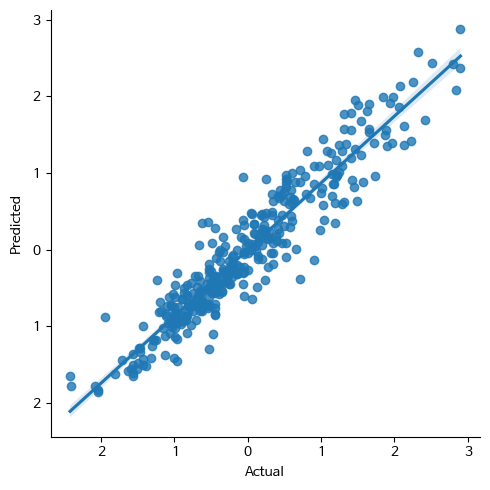

In [ ]:
sns.lmplot(x ='Actual', y ='Predicted', data = output)

### 9.3 모델 검정

In [ ]:
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
print('MSE: %.3f' % mean_squared_error(y_test_std,y_pred))             # y_train -> y_train_std
print('MAE: %.3f' % mean_absolute_error(y_test_std,y_pred))            # y_train -> y_train_std
print('RMSE: %.3f' % np.sqrt(mean_squared_error(y_test_std,y_pred)))   # y_train -> y_train_std
print('R2: %.3f' % r2_score(y_test_std,y_pred))                        # y_train -> y_train_std

MSE: 0.108
MAE: 0.244
RMSE: 0.329
R2: 0.893
